# 🛒 E-Commerce Superstore Sales Analysis
## End-to-End Data Analysis Pipeline

**Dataset:** Sample Superstore (9,994 records × 21 features)  
**Goal:** Perform EDA, Data Cleaning, Preprocessing, Feature Engineering & export clean dataset for PostgreSQL

---
### 📋 Table of Contents
1. [Import Libraries](#1-import-libraries)
2. [Load Dataset](#2-load-dataset)
3. [Dataset Overview](#3-dataset-overview)
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis)
5. [Data Cleaning](#5-data-cleaning)
6. [Preprocessing](#6-preprocessing)
7. [Feature Engineering](#7-feature-engineering)
8. [Data Visualization](#8-data-visualization)
9. [Export Clean Dataset for PostgreSQL](#9-export-clean-dataset)

---
## 1. Import Libraries

In [1]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ─── Styling ──────────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
sns.set_palette('Set2')

# ─── Pandas Display Settings ──────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 2. Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\RUDRA BARMAN\Desktop\Data Analyst\superstore sales analysis\Sample - Superstore.csv", encoding='latin1')

print(f'✅ Dataset loaded successfully!')
print(f'📊 Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded successfully!
📊 Shape : 9,994 rows × 21 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.0000,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.0000,219.5820
2,3,CA-2016-138688,06-12-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.0000,6.8714
3,4,US-2015-108966,10-11-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.4500,-383.0310
4,5,US-2015-108966,10-11-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.2000,2.5164


---
## 3. Dataset Overview

In [3]:
# ── Column Info ───────────────────────────────────────────────────────────────
print('='*60)
print('COLUMN INFORMATION')
print('='*60)
df.info()

COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   fl

In [4]:
# ── Statistical Summary ───────────────────────────────────────────────────────
print('='*60)
print('STATISTICAL SUMMARY – Numerical Columns')
print('='*60)
df.describe().T.style.background_gradient(cmap='Blues')

STATISTICAL SUMMARY – Numerical Columns


,count,mean,std,min,25%,50%,75%,max
Row ID,9994.000000,4997.500000,2885.163629,1.000000,2499.250000,4997.500000,7495.750000,9994.000000
Postal Code,9994.000000,55190.379428,32063.693350,1040.000000,23223.000000,56430.500000,90008.000000,99301.000000
Sales,9994.000000,229.858001,623.245101,0.444000,17.280000,54.490000,209.940000,22638.480000
Quantity,9994.000000,3.789574,2.225110,1.000000,2.000000,3.000000,5.000000,14.000000
Discount,9994.000000,0.156203,0.206452,0.000000,0.000000,0.200000,0.200000,0.800000
Profit,9994.000000,28.656896,234.260108,-6599.978000,1.728750,8.666500,29.364000,8399.976000


In [10]:
# ── Categorical Columns Summary ───────────────────────────────────────────────
print('='*60)
print('CATEGORICAL COLUMNS – Unique Value Counts')
print('='*60)
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"  {col:<20} → {df[col].nunique():>4} unique values")

CATEGORICAL COLUMNS – Unique Value Counts
  Order ID             → 5009 unique values
  Order Date           → 1237 unique values
  Ship Date            → 1334 unique values
  Ship Mode            →    4 unique values
  Customer ID          →  793 unique values
  Customer Name        →  793 unique values
  Segment              →    3 unique values
  Country              →    1 unique values
  City                 →  531 unique values
  State                →   49 unique values
  Region               →    4 unique values
  Product ID           → 1862 unique values
  Category             →    3 unique values
  Sub-Category         →   17 unique values
  Product Name         → 1850 unique values


In [11]:
# ── Sample Value Frequencies ──────────────────────────────────────────────────
for col in ['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode']:
    print(f'\n📌 {col}:')
    print(df[col].value_counts().to_string())


📌 Category:
Category
Office Supplies    6026
Furniture          2121
Technology         1847

📌 Sub-Category:
Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68

📌 Segment:
Segment
Consumer       5191
Corporate      3020
Home Office    1783

📌 Region:
Region
West       3203
East       2848
Central    2323
South      1620

📌 Ship Mode:
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543


---
## 4. Exploratory Data Analysis

In [12]:
# ── 4.1 Missing Values ────────────────────────────────────────────────────────
print('='*60)
print('MISSING VALUES ANALYSIS')
print('='*60)

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0]

if missing.empty:
    print('✅ No missing values found in any column!')
else:
    print(missing)

MISSING VALUES ANALYSIS
✅ No missing values found in any column!


In [13]:
# ── 4.2 Duplicate Check ───────────────────────────────────────────────────────
dup_rows = df.duplicated().sum()
dup_orders = df.duplicated(subset=['Order ID', 'Product ID']).sum()

print(f'Duplicate full rows      : {dup_rows}')
print(f'Duplicate Order+Product  : {dup_orders}')

Duplicate full rows      : 0
Duplicate Order+Product  : 8


In [14]:
# ── 4.3 Negative Profit Analysis ─────────────────────────────────────────────
neg_profit = df[df['Profit'] < 0]
print(f'Orders with Negative Profit  : {len(neg_profit):,} ({len(neg_profit)/len(df)*100:.1f}%)')
print(f'Total Loss Amount            : ${neg_profit["Profit"].sum():,.2f}')
print(f'\nTop Loss-Making Sub-Categories:')
print(neg_profit.groupby('Sub-Category')['Profit'].sum().sort_values().head(10))

Orders with Negative Profit  : 1,871 (18.7%)
Total Loss Amount            : $-156,131.29

Top Loss-Making Sub-Categories:
Sub-Category
Binders       -38510.4964
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9880.8413
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Name: Profit, dtype: float64


In [15]:
# ── 4.4 Outlier Detection using IQR ──────────────────────────────────────────
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

print('='*60)
print('OUTLIER DETECTION (IQR Method)')
print('='*60)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'  {col:<12} → {len(outliers):>4} outliers  | Range: [{lower:.2f}, {upper:.2f}]')

OUTLIER DETECTION (IQR Method)
  Sales        → 1167 outliers  | Range: [-271.71, 498.93]
  Quantity     →  170 outliers  | Range: [-2.50, 9.50]
  Discount     →  856 outliers  | Range: [-0.30, 0.50]
  Profit       → 1881 outliers  | Range: [-39.72, 70.82]


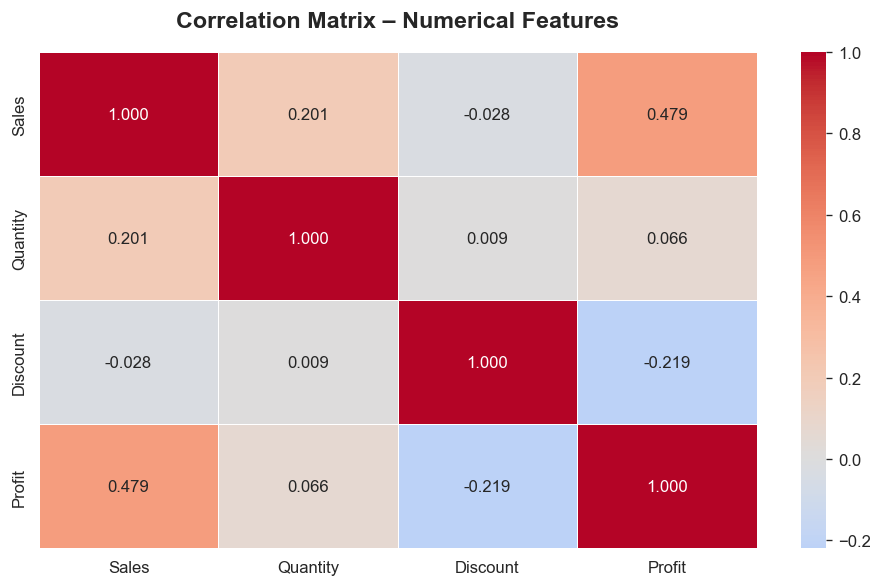

In [16]:
# ── 4.5 Correlation Matrix ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix – Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## 5. Data Cleaning

In [17]:
# ── 5.1 Work on a clean copy ──────────────────────────────────────────────────
df_clean = df.copy()
print(f'Shape before cleaning: {df_clean.shape}')

Shape before cleaning: (9994, 21)


In [18]:
# ── 5.2 Convert Date Columns ──────────────────────────────────────────────────
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'], dayfirst=True)
df_clean['Ship Date']  = pd.to_datetime(df_clean['Ship Date'],  dayfirst=True)

print('✅ Date columns converted to datetime')
print(f'   Order Date range: {df_clean["Order Date"].min().date()} → {df_clean["Order Date"].max().date()}')
print(f'   Ship Date  range: {df_clean["Ship Date"].min().date()}  → {df_clean["Ship Date"].max().date()}')

✅ Date columns converted to datetime
   Order Date range: 2014-01-02 → 2017-12-30
   Ship Date  range: 2014-01-04  → 2018-05-01


In [19]:
# ── 5.3 Postal Code → String (leading zeros preservation) ─────────────────────
df_clean['Postal Code'] = df_clean['Postal Code'].astype(str).str.zfill(5)
print('✅ Postal Code converted to zero-padded string')
print(df_clean['Postal Code'].head())

✅ Postal Code converted to zero-padded string
0    42420
1    42420
2    90036
3    33311
4    33311
Name: Postal Code, dtype: object


In [20]:
# ── 5.4 Standardise String Columns (strip whitespace, title case) ─────────────
str_cols = ['Ship Mode', 'Segment', 'Country', 'City', 'State',
            'Region', 'Category', 'Sub-Category']

for col in str_cols:
    df_clean[col] = df_clean[col].str.strip().str.title()

print('✅ String columns standardised')

✅ String columns standardised


In [21]:
# ── 5.5 Drop Redundant Column ─────────────────────────────────────────────────
# 'Row ID' is just an index; 'Country' has only 1 unique value → both can be dropped
print(f'Unique countries: {df_clean["Country"].unique()}')
df_clean.drop(columns=['Row ID', 'Country'], inplace=True)
print('✅ Dropped: Row ID, Country (single value column)')

Unique countries: ['United States']
✅ Dropped: Row ID, Country (single value column)


In [22]:
# ── 5.6 Validate Sales & Quantity ─────────────────────────────────────────────
invalid_sales = df_clean[df_clean['Sales'] <= 0]
invalid_qty   = df_clean[df_clean['Quantity'] <= 0]
print(f'Rows with Sales ≤ 0    : {len(invalid_sales)}')
print(f'Rows with Quantity ≤ 0 : {len(invalid_qty)}')

print(f'\nShape after cleaning: {df_clean.shape}')

Rows with Sales ≤ 0    : 0
Rows with Quantity ≤ 0 : 0

Shape after cleaning: (9994, 19)


---
## 6. Preprocessing

In [23]:
# ── 6.1 Encode Categorical Columns with Label Encoding ────────────────────────
from sklearn.preprocessing import LabelEncoder

encode_cols = ['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']
le = LabelEncoder()

for col in encode_cols:
    df_clean[col + '_Encoded'] = le.fit_transform(df_clean[col])
    print(f'  {col:<20} → {col}_Encoded  (classes: {list(le.classes_)})')

  Ship Mode            → Ship Mode_Encoded  (classes: ['First Class', 'Same Day', 'Second Class', 'Standard Class'])
  Segment              → Segment_Encoded  (classes: ['Consumer', 'Corporate', 'Home Office'])
  Region               → Region_Encoded  (classes: ['Central', 'East', 'South', 'West'])
  Category             → Category_Encoded  (classes: ['Furniture', 'Office Supplies', 'Technology'])
  Sub-Category         → Sub-Category_Encoded  (classes: ['Accessories', 'Appliances', 'Art', 'Binders', 'Bookcases', 'Chairs', 'Copiers', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Machines', 'Paper', 'Phones', 'Storage', 'Supplies', 'Tables'])


In [24]:
# ── 6.2 Normalise Numerical Columns (Min-Max) ─────────────────────────────────
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scale_cols = ['Sales', 'Quantity', 'Profit']

df_clean[['Sales_Scaled', 'Quantity_Scaled', 'Profit_Scaled']] = \
    scaler.fit_transform(df_clean[scale_cols])

print('✅ Min-Max scaling applied to Sales, Quantity, Profit')
df_clean[['Sales', 'Sales_Scaled', 'Profit', 'Profit_Scaled']].head()

✅ Min-Max scaling applied to Sales, Quantity, Profit


,Sales,Sales_Scaled,Profit,Profit_Scaled
0,261.9600,0.0116,41.9136,0.4428
1,731.9400,0.0323,219.5820,0.4546
2,14.6200,0.0006,6.8714,0.4405
3,957.5775,0.0423,-383.0310,0.4145
4,22.3680,0.0010,2.5164,0.4402


In [25]:
# ── 6.3 Discount Binning → Discount Tier ─────────────────────────────────────
bins   = [-0.001, 0.0, 0.2, 0.4, 0.8]
labels = ['No Discount', 'Low (0–20%)', 'Medium (20–40%)', 'High (40–80%)']

df_clean['Discount_Tier'] = pd.cut(df_clean['Discount'], bins=bins, labels=labels)

print('Discount Tier Distribution:')
print(df_clean['Discount_Tier'].value_counts())

Discount Tier Distribution:
Discount_Tier
No Discount        4798
Low (0–20%)        3803
High (40–80%)       933
Medium (20–40%)     460
Name: count, dtype: int64


---
## 7. Feature Engineering

In [26]:
# ── 7.1 Shipping Duration ─────────────────────────────────────────────────────
df_clean['Shipping_Duration'] = (df_clean['Ship Date'] - df_clean['Order Date']).dt.days

# Flag and handle anomalous negative shipping durations
neg_ship = df_clean[df_clean['Shipping_Duration'] < 0]
print(f'⚠️  Rows with negative Shipping Duration : {len(neg_ship)}')
if len(neg_ship) > 0:
    median_ship = df_clean[df_clean['Shipping_Duration'] >= 0]['Shipping_Duration'].median()
    df_clean.loc[df_clean['Shipping_Duration'] < 0, 'Shipping_Duration'] = median_ship
    print(f'   → Replaced with median shipping duration: {median_ship} days')

print('\nShipping Duration Stats (after fix):')
print(df_clean['Shipping_Duration'].describe())

⚠️  Rows with negative Shipping Duration : 1708
   → Replaced with median shipping duration: 5.0 days

Shipping Duration Stats (after fix):
count   9994.0000
mean      35.4636
std       54.5510
min        0.0000
25%        4.0000
50%        5.0000
75%       61.0000
max      214.0000
Name: Shipping_Duration, dtype: float64


In [27]:
# ── 7.2 Date-Based Features ───────────────────────────────────────────────────
df_clean['Order_Year']    = df_clean['Order Date'].dt.year
df_clean['Order_Month']   = df_clean['Order Date'].dt.month
df_clean['Order_Quarter'] = df_clean['Order Date'].dt.quarter
df_clean['Order_WeekDay'] = df_clean['Order Date'].dt.dayofweek   # 0=Mon … 6=Sun
df_clean['Order_DayName'] = df_clean['Order Date'].dt.day_name()
df_clean['Order_MonthName'] = df_clean['Order Date'].dt.month_name()

print('✅ Date features extracted')
df_clean[['Order Date', 'Order_Year', 'Order_Month', 'Order_Quarter',
          'Order_DayName', 'Order_MonthName']].head()

✅ Date features extracted


,Order Date,Order_Year,Order_Month,Order_Quarter,Order_DayName,Order_MonthName
0,2016-08-11,2016,8,3,Thursday,August
1,2016-08-11,2016,8,3,Thursday,August
2,2016-12-06,2016,12,4,Tuesday,December
3,2015-11-10,2015,11,4,Tuesday,November
4,2015-11-10,2015,11,4,Tuesday,November


In [28]:
# ── 7.3 Profit Margin % ───────────────────────────────────────────────────────
df_clean['Profit_Margin_%'] = (df_clean['Profit'] / df_clean['Sales'] * 100).round(4)
print('Profit Margin % Stats:')
print(df_clean['Profit_Margin_%'].describe())

Profit Margin % Stats:
count   9994.0000
mean      12.0314
std       46.6754
min     -275.0000
25%        7.5000
50%       27.0000
75%       36.2500
max       50.0000
Name: Profit_Margin_%, dtype: float64


In [29]:
# ── 7.4 Revenue Per Unit ──────────────────────────────────────────────────────
df_clean['Revenue_Per_Unit'] = (df_clean['Sales'] / df_clean['Quantity']).round(4)

print('✅ Revenue_Per_Unit created')
df_clean[['Sales', 'Quantity', 'Revenue_Per_Unit']].head()

✅ Revenue_Per_Unit created


,Sales,Quantity,Revenue_Per_Unit
0,261.9600,2,130.9800
1,731.9400,3,243.9800
2,14.6200,2,7.3100
3,957.5775,5,191.5155
4,22.3680,2,11.1840


In [30]:
# ── 7.5 Profit Category Tagging ───────────────────────────────────────────────
def profit_label(profit):
    if profit > 100:   return 'High Profit'
    elif profit > 0:   return 'Low Profit'
    elif profit == 0:  return 'Break-Even'
    else:              return 'Loss'

df_clean['Profit_Category'] = df_clean['Profit'].apply(profit_label)

print('Profit Category Distribution:')
print(df_clean['Profit_Category'].value_counts())

Profit Category Distribution:
Profit_Category
Low Profit     7168
Loss           1871
High Profit     890
Break-Even       65
Name: count, dtype: int64


In [31]:
# ── 7.6 Is_High_Discount Flag ─────────────────────────────────────────────────
df_clean['Is_High_Discount'] = (df_clean['Discount'] > 0.3).astype(int)

print('High Discount Flag:')
print(df_clean['Is_High_Discount'].value_counts())

High Discount Flag:
Is_High_Discount
0    8828
1    1166
Name: count, dtype: int64


In [32]:
# ── 7.7 YearMonth for Time Series Grouping ────────────────────────────────────
df_clean['Year_Month'] = df_clean['Order Date'].dt.to_period('M').astype(str)

print('✅ Year_Month column created')
print(df_clean['Year_Month'].unique()[:12])

✅ Year_Month column created
['2016-08' '2016-12' '2015-11' '2014-09' '2017-04' '2016-05' '2014-11'
 '2014-05' '2014-08' '2016-09' '2017-07' '2015-09']


In [33]:
# ── 7.8 Final Feature Summary ─────────────────────────────────────────────────
print('='*60)
print(f'Total Columns after Feature Engineering: {df_clean.shape[1]}')
print('='*60)
print(df_clean.dtypes.to_string())

Total Columns after Feature Engineering: 40
Order ID                        object
Order Date              datetime64[ns]
Ship Date               datetime64[ns]
Ship Mode                       object
Customer ID                     object
Customer Name                   object
Segment                         object
City                            object
State                           object
Postal Code                     object
Region                          object
Product ID                      object
Category                        object
Sub-Category                    object
Product Name                    object
Sales                          float64
Quantity                         int64
Discount                       float64
Profit                         float64
Ship Mode_Encoded                int64
Segment_Encoded                  int64
Region_Encoded                   int64
Category_Encoded                 int64
Sub-Category_Encoded             int64
Sales_Scaled        

---
## 8. Data Visualization

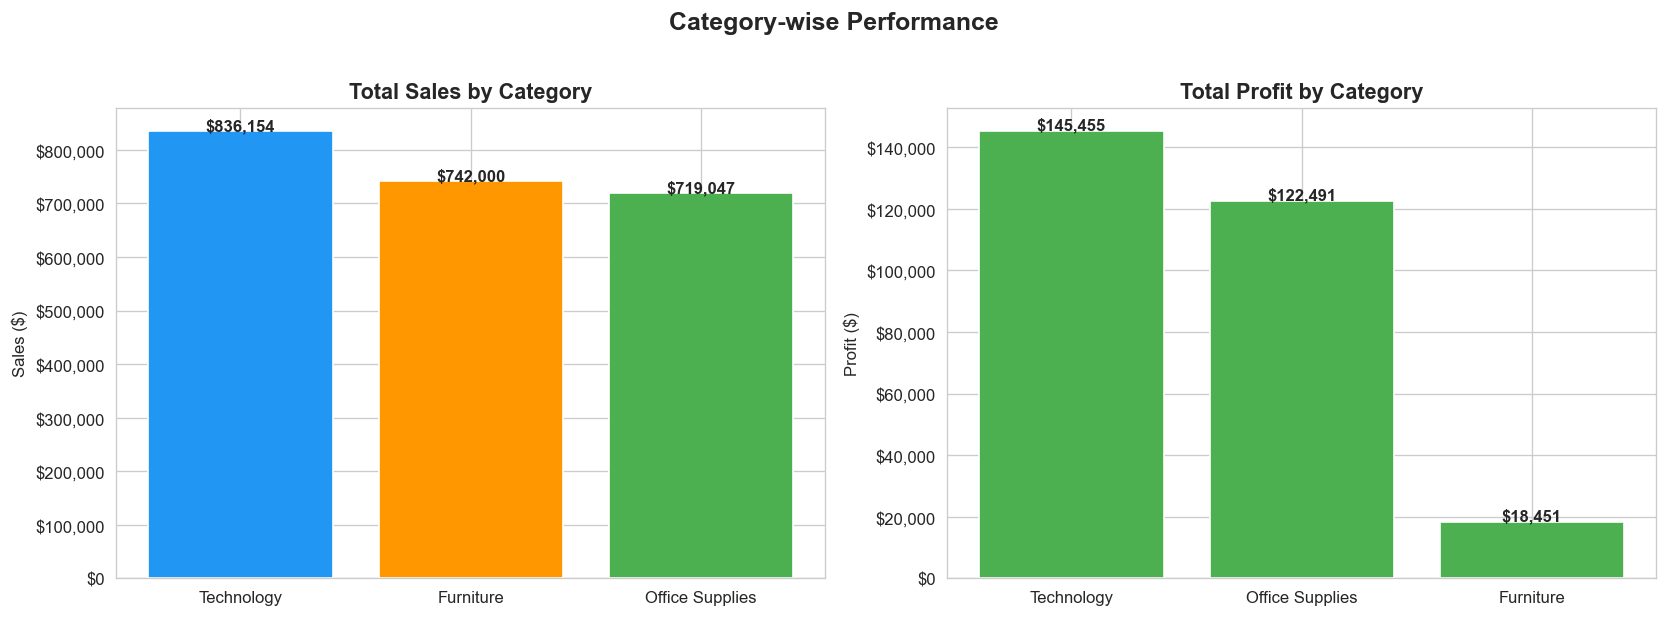

In [34]:
# ── 8.1 Sales & Profit by Category ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_sales  = df_clean.groupby('Category')['Sales'].sum().sort_values(ascending=False)
cat_profit = df_clean.groupby('Category')['Profit'].sum().sort_values(ascending=False)

bars1 = axes[0].bar(cat_sales.index, cat_sales.values, color=['#2196F3','#FF9800','#4CAF50'], edgecolor='white')
axes[0].set_title('Total Sales by Category', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'${bar.get_height():,.0f}', ha='center', fontsize=10, fontweight='bold')

colors2 = ['#4CAF50' if v > 0 else '#F44336' for v in cat_profit.values]
bars2 = axes[1].bar(cat_profit.index, cat_profit.values, color=colors2, edgecolor='white')
axes[1].set_title('Total Profit by Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f'${bar.get_height():,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Category-wise Performance', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_01_category_performance.png', bbox_inches='tight', dpi=150)
plt.show()

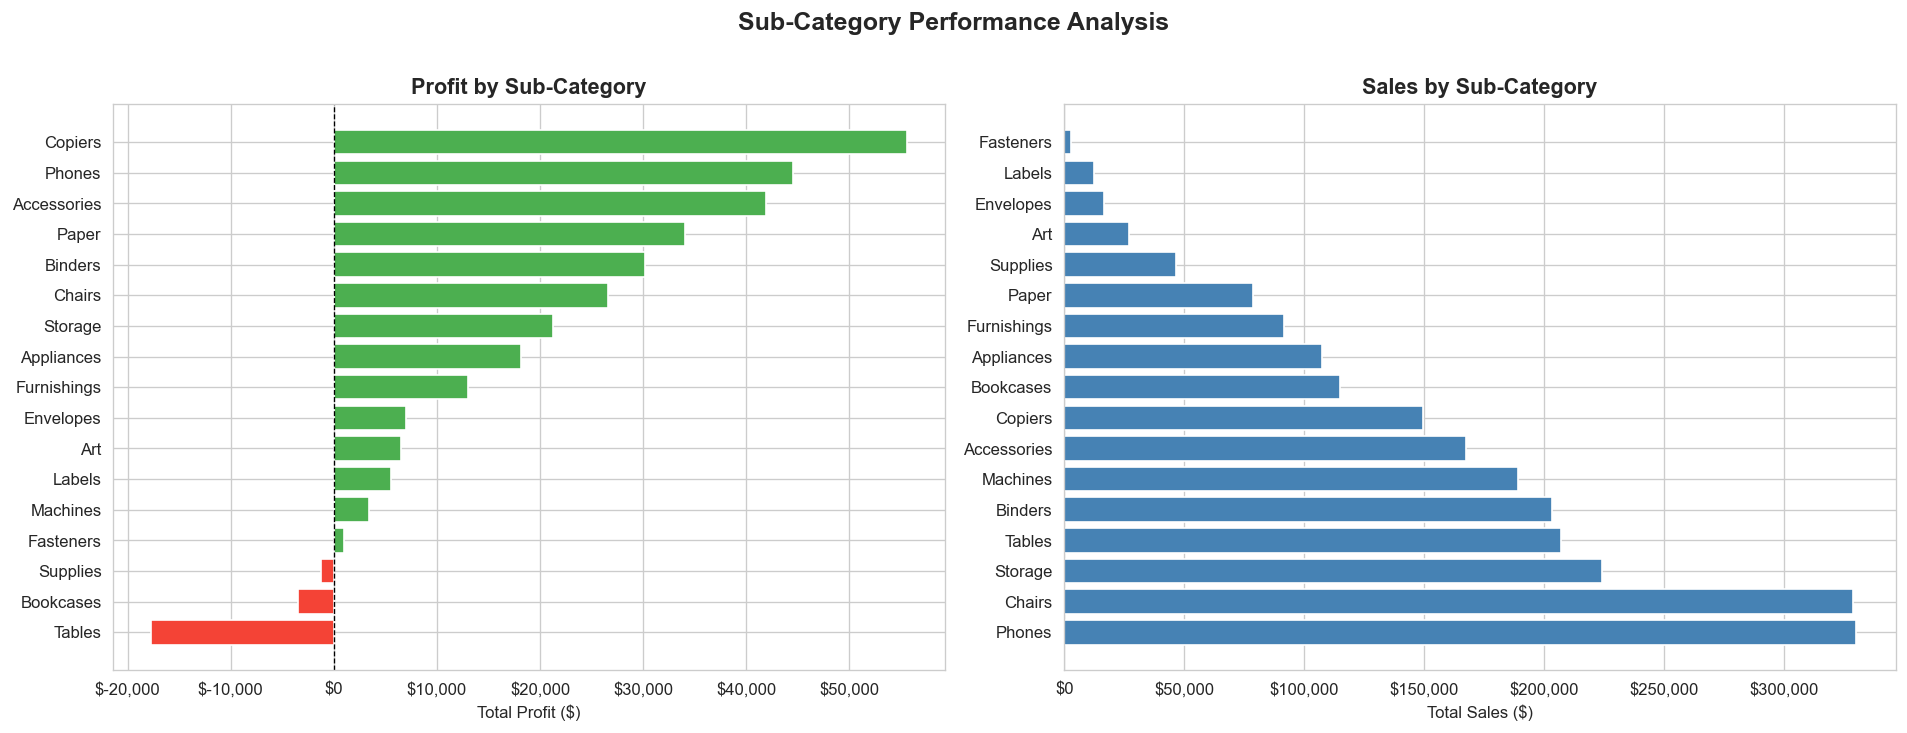

In [35]:
# ── 8.2 Sub-Category Deep Dive ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sub_profit = df_clean.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#F44336' if v < 0 else '#4CAF50' for v in sub_profit.values]

axes[0].barh(sub_profit.index, sub_profit.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Profit by Sub-Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Profit ($)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sub_sales = df_clean.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
axes[1].barh(sub_sales.index, sub_sales.values, color='steelblue', edgecolor='white')
axes[1].set_title('Sales by Sub-Category', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Sales ($)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Sub-Category Performance Analysis', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_02_subcategory_performance.png', bbox_inches='tight', dpi=150)
plt.show()

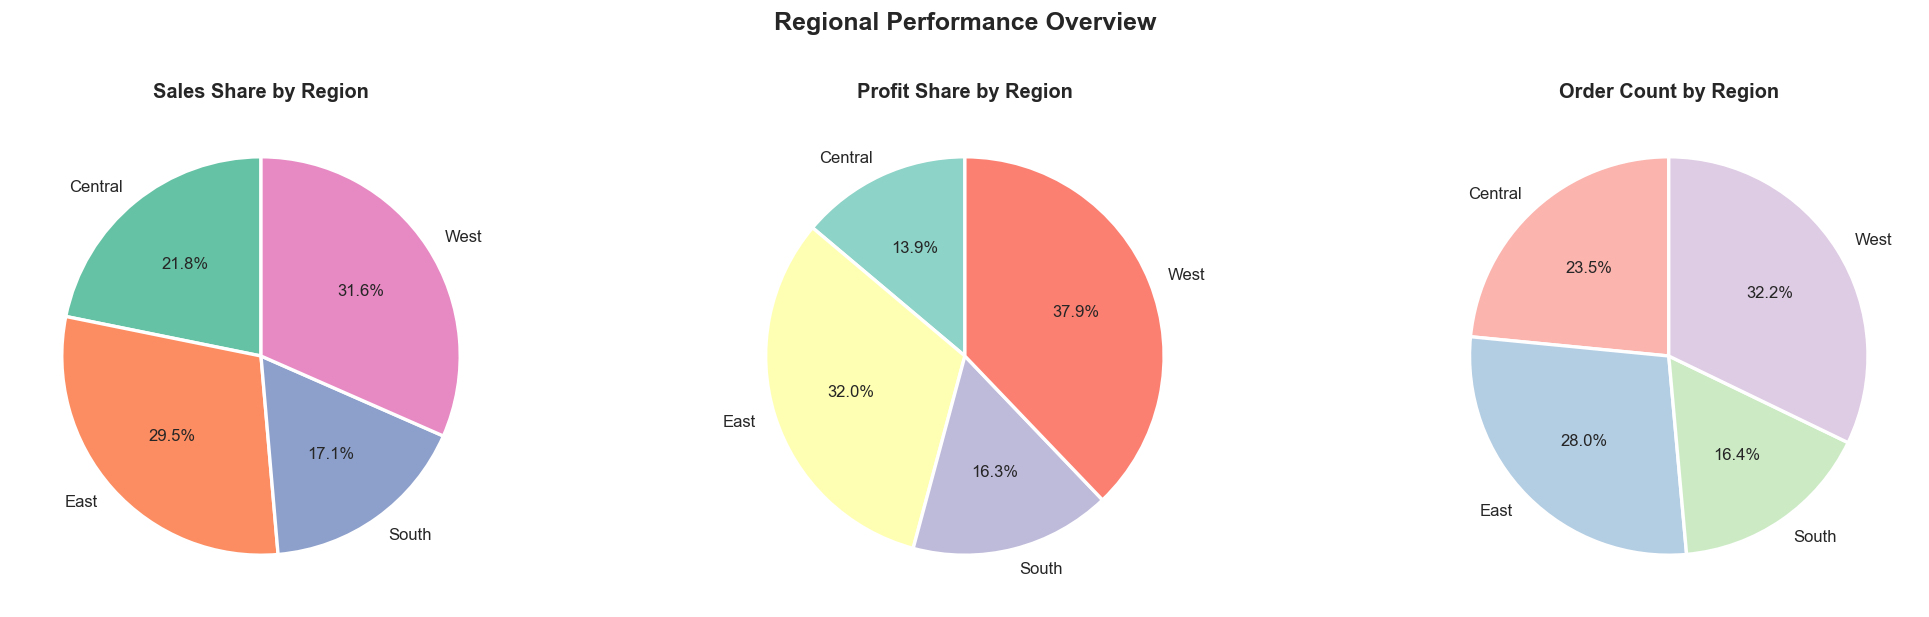

In [36]:
# ── 8.3 Regional Analysis ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

region_sales   = df_clean.groupby('Region')['Sales'].sum()
region_profit  = df_clean.groupby('Region')['Profit'].sum()
region_orders  = df_clean.groupby('Region')['Order ID'].nunique()

axes[0].pie(region_sales, labels=region_sales.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 4), startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Sales Share by Region', fontsize=12, fontweight='bold')

axes[1].pie(region_profit, labels=region_profit.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set3', 4), startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Profit Share by Region', fontsize=12, fontweight='bold')

axes[2].pie(region_orders, labels=region_orders.index, autopct='%1.1f%%',
            colors=sns.color_palette('Pastel1', 4), startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title('Order Count by Region', fontsize=12, fontweight='bold')

plt.suptitle('Regional Performance Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_03_regional_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

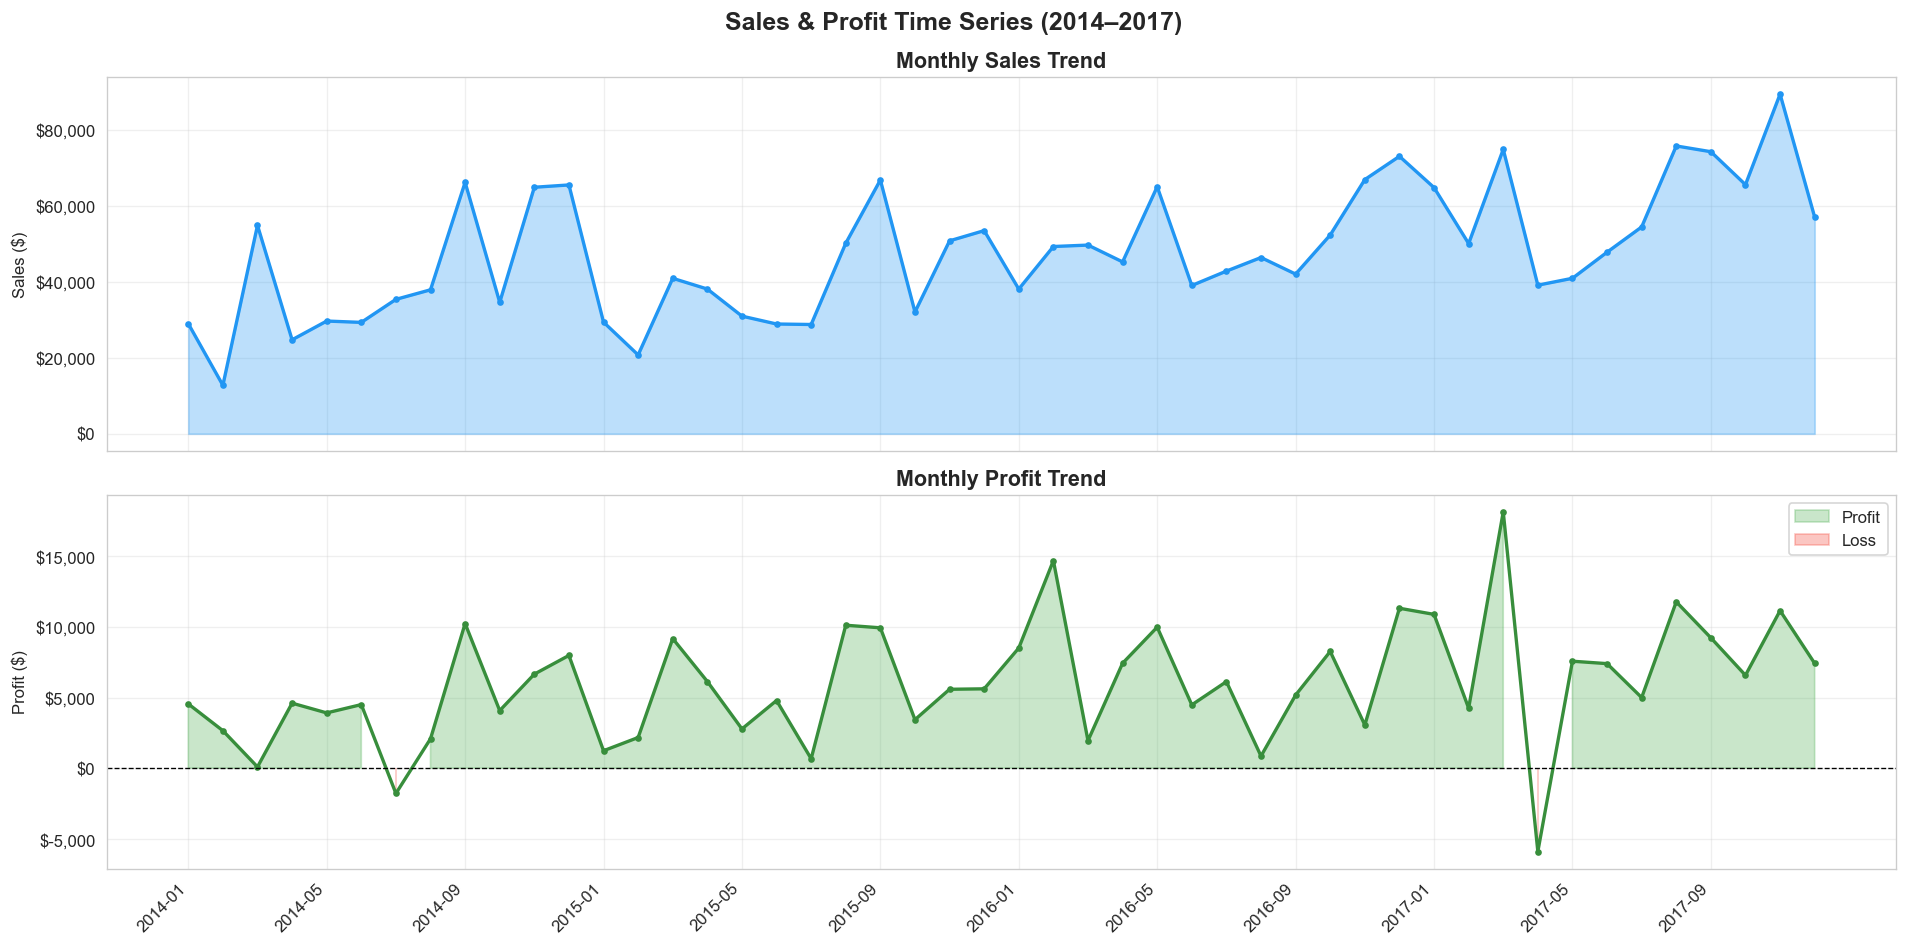

In [37]:
# ── 8.4 Monthly Sales Trend (Time Series) ─────────────────────────────────────
monthly = df_clean.groupby('Year_Month').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','nunique')
).reset_index()
monthly = monthly.sort_values('Year_Month')

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].fill_between(monthly.index, monthly['Sales'], alpha=0.3, color='#2196F3')
axes[0].plot(monthly.index, monthly['Sales'], color='#2196F3', linewidth=2, marker='o', markersize=3)
axes[0].set_title('Monthly Sales Trend', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(monthly.index, monthly['Profit'],
                     where=(monthly['Profit'] >= 0), alpha=0.3, color='#4CAF50', label='Profit')
axes[1].fill_between(monthly.index, monthly['Profit'],
                     where=(monthly['Profit'] < 0),  alpha=0.3, color='#F44336', label='Loss')
axes[1].plot(monthly.index, monthly['Profit'], color='#388E3C', linewidth=2, marker='o', markersize=3)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Monthly Profit Trend', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

tick_step = max(1, len(monthly) // 12)
axes[1].set_xticks(monthly.index[::tick_step])
axes[1].set_xticklabels(monthly['Year_Month'].iloc[::tick_step], rotation=45, ha='right')

plt.suptitle('Sales & Profit Time Series (2014–2017)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_04_time_series.png', bbox_inches='tight', dpi=150)
plt.show()

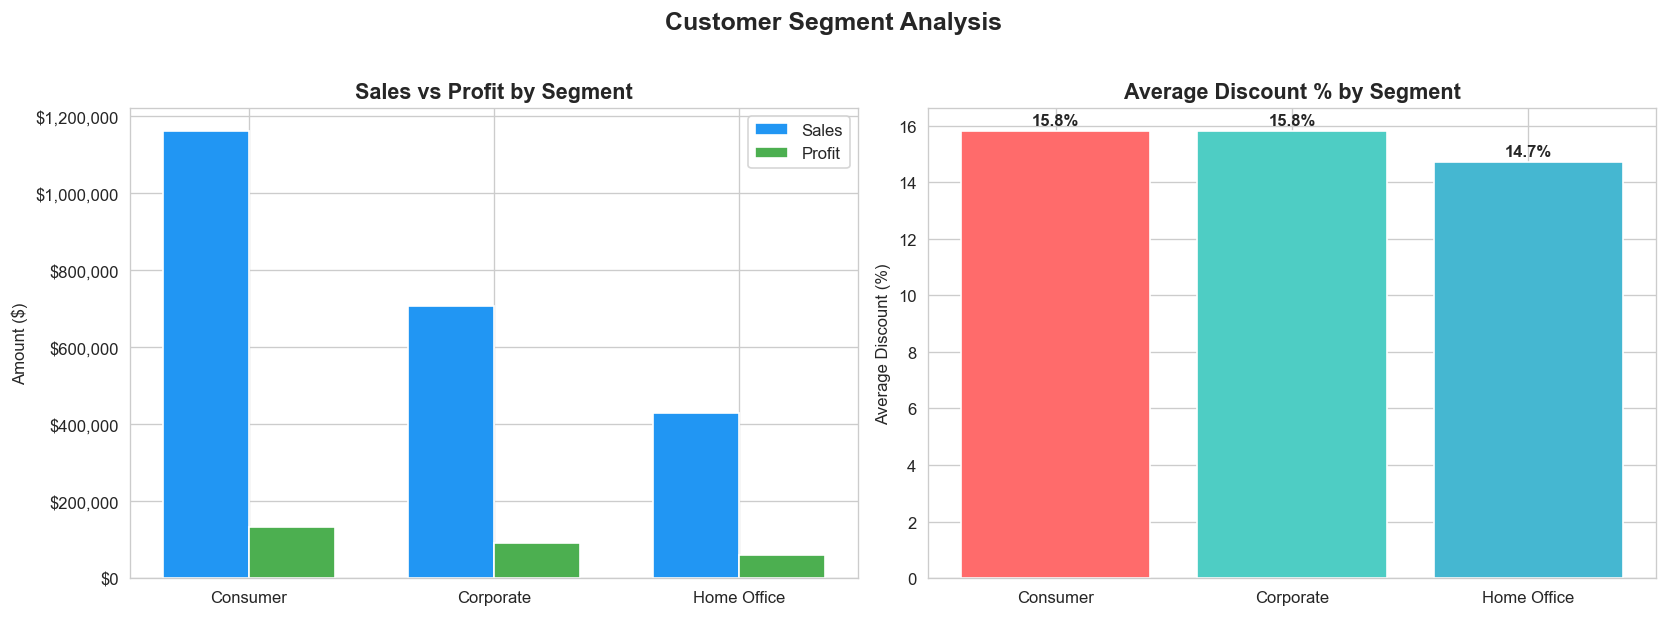

In [38]:
# ── 8.5 Segment-wise Analysis ─────────────────────────────────────────────────
seg = df_clean.groupby('Segment').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','nunique'),
    Avg_Discount=('Discount','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(seg))
width = 0.35
axes[0].bar(x - width/2, seg['Sales'], width, label='Sales', color='#2196F3', edgecolor='white')
axes[0].bar(x + width/2, seg['Profit'], width, label='Profit', color='#4CAF50', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(seg['Segment'])
axes[0].set_title('Sales vs Profit by Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Amount ($)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend()

axes[1].bar(seg['Segment'], seg['Avg_Discount']*100,
            color=['#FF6B6B','#4ECDC4','#45B7D1'], edgecolor='white')
axes[1].set_title('Average Discount % by Segment', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Discount (%)')
for i, v in enumerate(seg['Avg_Discount']*100):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Customer Segment Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_05_segment_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

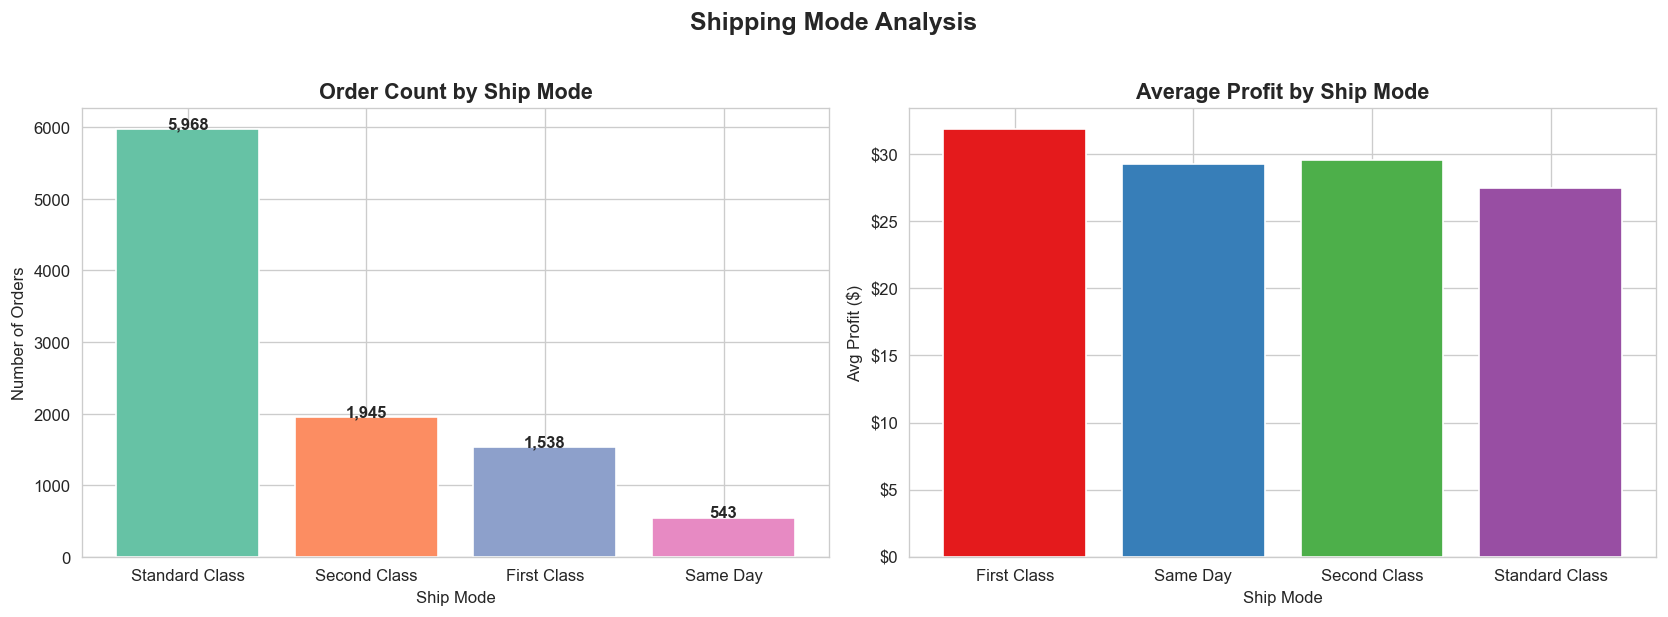

In [39]:
# ── 8.6 Ship Mode Distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ship_counts = df_clean['Ship Mode'].value_counts()
ship_profit = df_clean.groupby('Ship Mode')['Profit'].mean()

axes[0].bar(ship_counts.index, ship_counts.values,
            color=sns.color_palette('Set2', 4), edgecolor='white')
axes[0].set_title('Order Count by Ship Mode', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Orders')
axes[0].set_xlabel('Ship Mode')
for i, v in enumerate(ship_counts.values):
    axes[0].text(i, v + 10, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(ship_profit.index, ship_profit.values,
            color=sns.color_palette('Set1', 4), edgecolor='white')
axes[1].set_title('Average Profit by Ship Mode', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Profit ($)')
axes[1].set_xlabel('Ship Mode')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Shipping Mode Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_06_ship_mode.png', bbox_inches='tight', dpi=150)
plt.show()

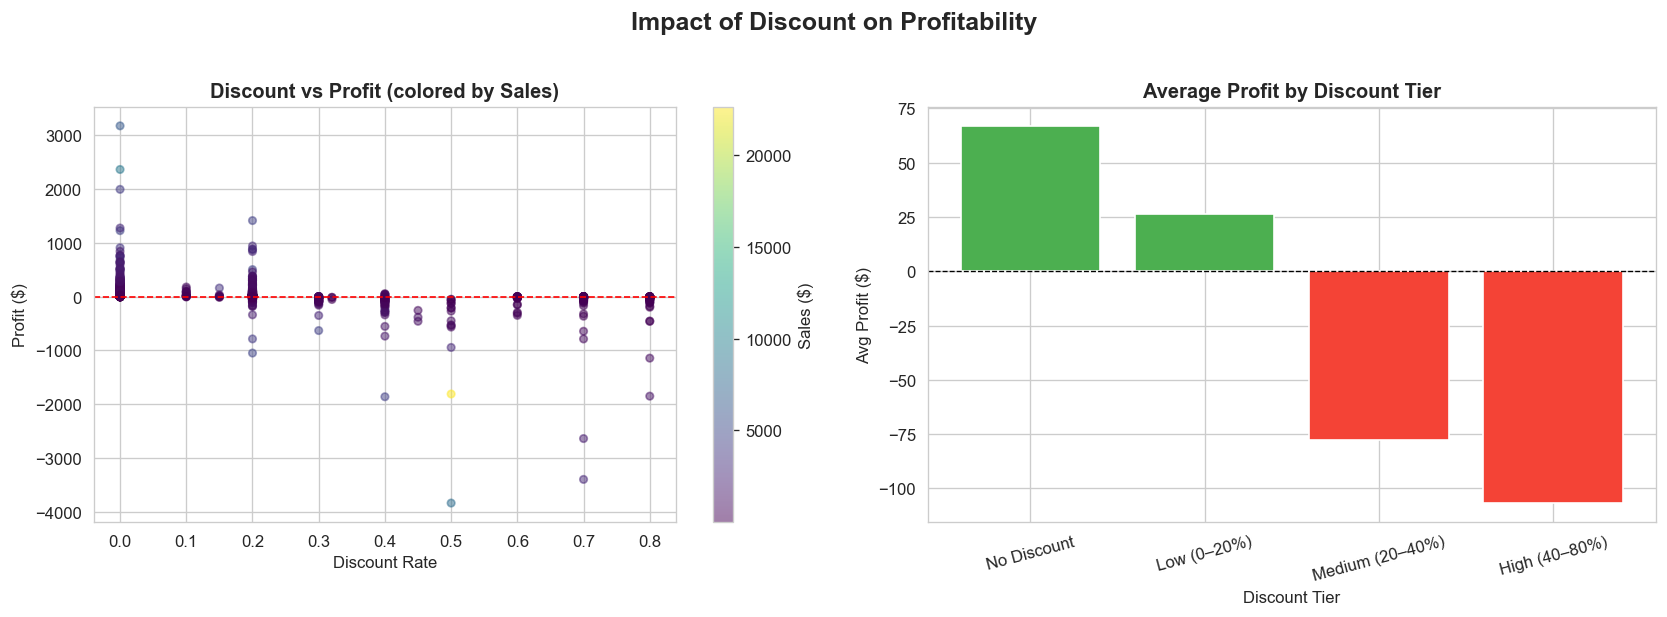

In [40]:
# ── 8.7 Discount vs Profit Scatter ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df_clean.sample(min(2000, len(df_clean)), random_state=42)

scatter = axes[0].scatter(sample['Discount'], sample['Profit'],
                          c=sample['Sales'], cmap='viridis', alpha=0.5, s=20)
plt.colorbar(scatter, ax=axes[0], label='Sales ($)')
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_title('Discount vs Profit (colored by Sales)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Discount Rate')
axes[0].set_ylabel('Profit ($)')

disc_profit = df_clean.groupby('Discount_Tier')['Profit'].mean()
colors3 = ['#4CAF50' if v > 0 else '#F44336' for v in disc_profit.values]
axes[1].bar(disc_profit.index.astype(str), disc_profit.values, color=colors3, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Average Profit by Discount Tier', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Avg Profit ($)')
axes[1].set_xlabel('Discount Tier')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Impact of Discount on Profitability', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_07_discount_profit.png', bbox_inches='tight', dpi=150)
plt.show()

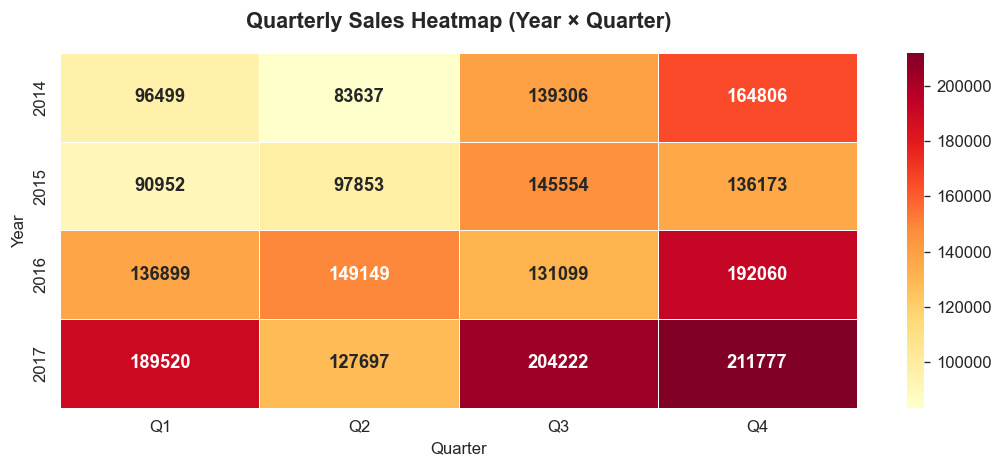

In [41]:
# ── 8.8 Quarterly Sales Heatmap ───────────────────────────────────────────────
pivot = df_clean.pivot_table(
    values='Sales', index='Order_Year',
    columns='Order_Quarter', aggfunc='sum'
)
pivot.columns = [f'Q{c}' for c in pivot.columns]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Quarterly Sales Heatmap (Year × Quarter)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Quarter')
ax.set_ylabel('Year')
plt.tight_layout()
plt.savefig('viz_08_quarterly_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

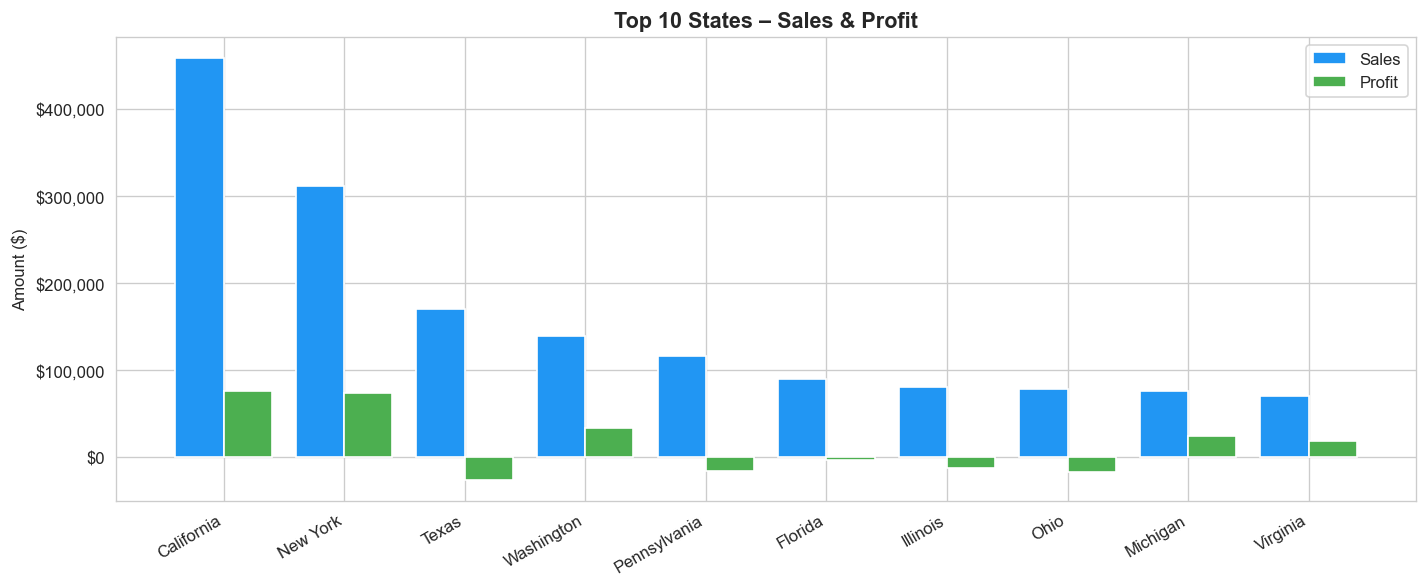

In [42]:
# ── 8.9 Top 10 States by Sales ────────────────────────────────────────────────
top_states = df_clean.groupby('State')[['Sales','Profit']].sum().nlargest(10, 'Sales')

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(top_states))
width = 0.4
ax.bar(x - width/2, top_states['Sales'], width, label='Sales', color='#2196F3', edgecolor='white')
ax.bar(x + width/2, top_states['Profit'], width, label='Profit', color='#4CAF50', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(top_states.index, rotation=30, ha='right')
ax.set_title('Top 10 States – Sales & Profit', fontsize=13, fontweight='bold')
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig('viz_09_top_states.png', bbox_inches='tight', dpi=150)
plt.show()

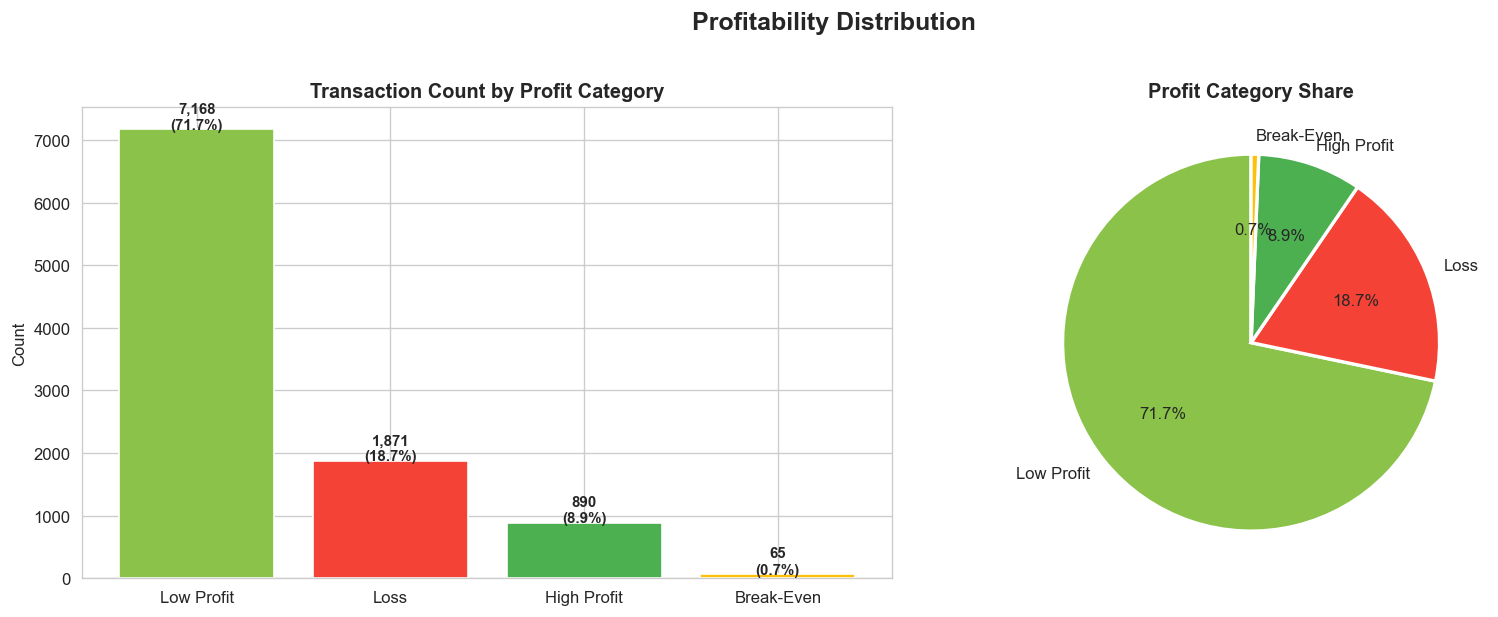

In [43]:
# ── 8.10 Profit Category Distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pc = df_clean['Profit_Category'].value_counts()
colors_pc = {'High Profit':'#4CAF50','Low Profit':'#8BC34A',
             'Break-Even':'#FFC107','Loss':'#F44336'}
bar_colors = [colors_pc[c] for c in pc.index]

axes[0].bar(pc.index, pc.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Transaction Count by Profit Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(pc.values):
    axes[0].text(i, v + 10, f'{v:,}\n({v/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].pie(pc.values, labels=pc.index, autopct='%1.1f%%',
            colors=bar_colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Profit Category Share', fontsize=12, fontweight='bold')

plt.suptitle('Profitability Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_10_profit_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

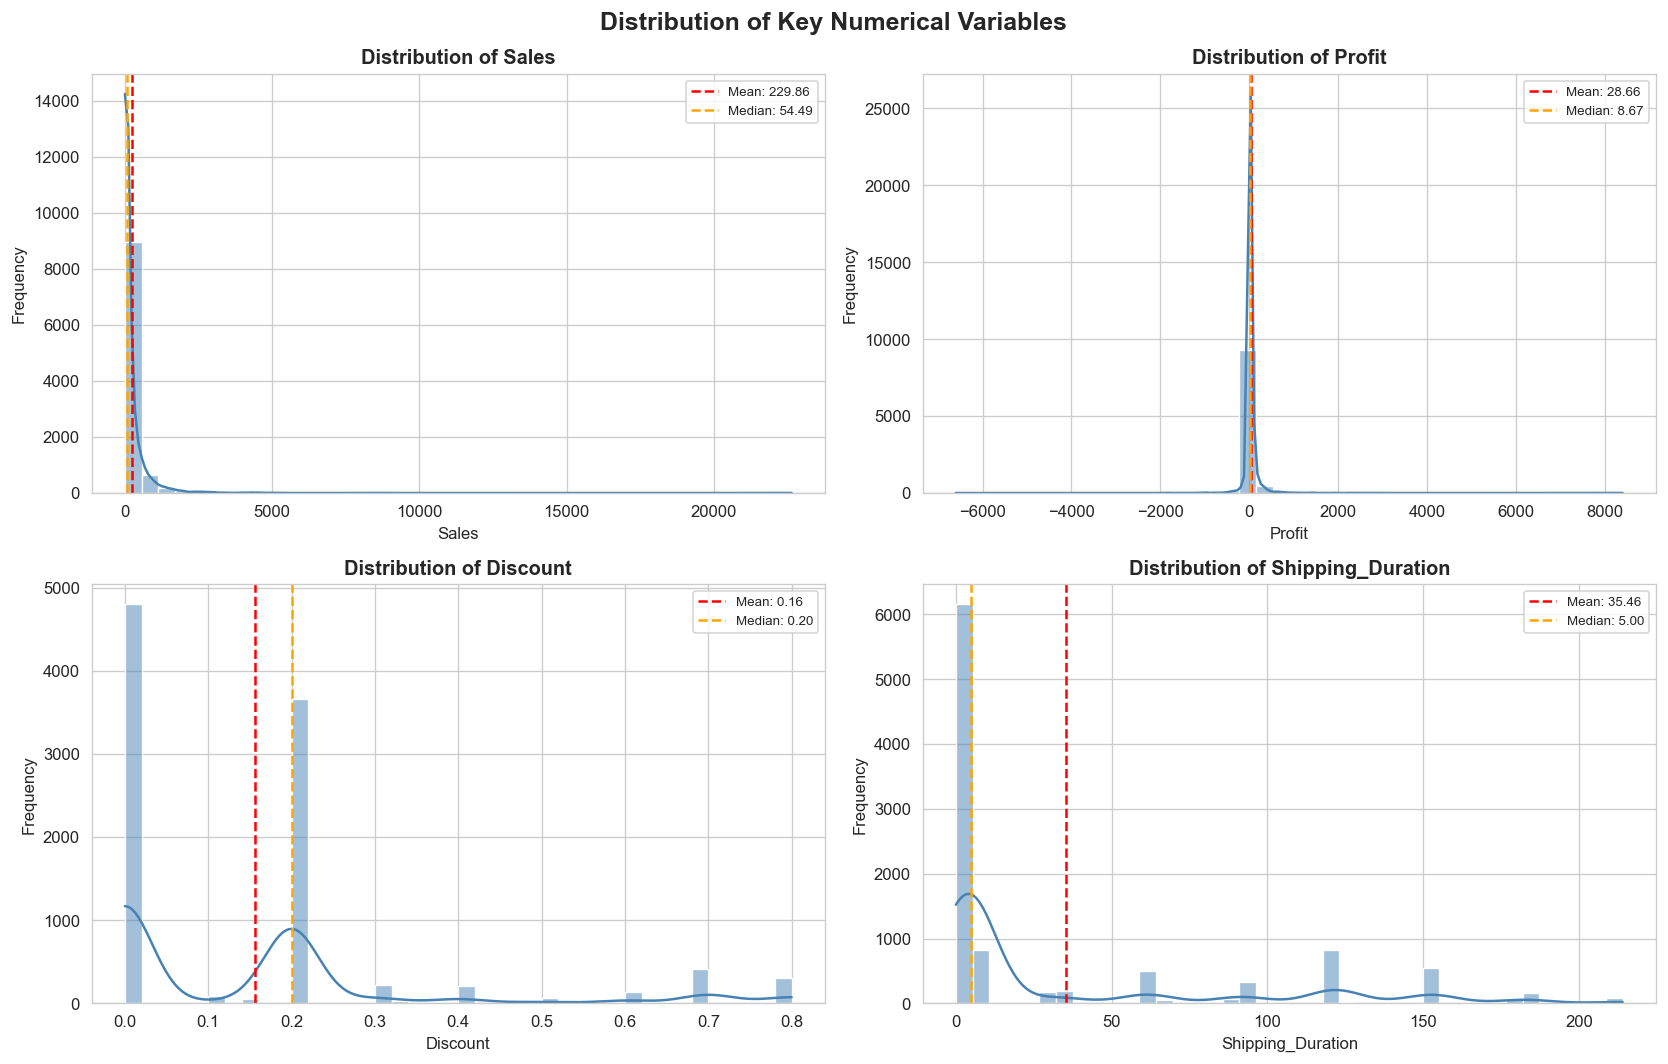

In [44]:
# ── 8.11 Distribution Plots – Numerical Features ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
num_cols = ['Sales', 'Profit', 'Discount', 'Shipping_Duration']

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df_clean[col], kde=True, ax=ax,
                 color='steelblue', edgecolor='white', bins=40)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Mean: {df_clean[col].mean():.2f}')
    ax.axvline(df_clean[col].median(), color='orange', linestyle='--', label=f'Median: {df_clean[col].median():.2f}')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Key Numerical Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz_11_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

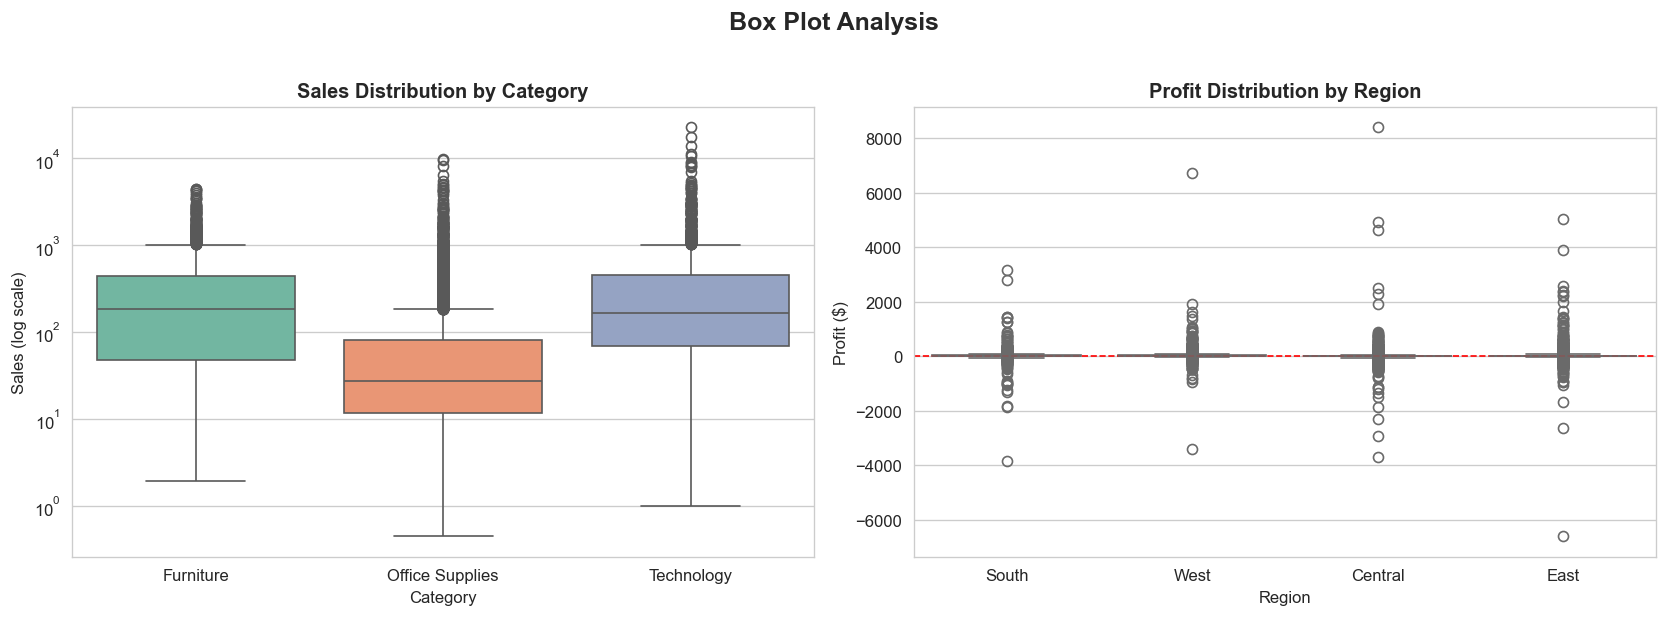

In [45]:
# ── 8.12 Box Plots – Sales by Category & Region ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x='Category', y='Sales', ax=axes[0],
            palette='Set2', showfliers=True)
axes[0].set_title('Sales Distribution by Category', fontsize=12, fontweight='bold')
axes[0].set_yscale('log')
axes[0].set_ylabel('Sales (log scale)')

sns.boxplot(data=df_clean, x='Region', y='Profit', ax=axes[1],
            palette='Set3', showfliers=True)
axes[1].set_title('Profit Distribution by Region', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Profit ($)')
axes[1].axhline(0, color='red', linewidth=1, linestyle='--')

plt.suptitle('Box Plot Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_12_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 9. Export Clean Dataset for PostgreSQL

In [46]:
# ── 9.1 Select Columns for Final Export ───────────────────────────────────────
export_cols = [
    # IDs
    'Order ID', 'Customer ID', 'Product ID',
    # Date Columns
    'Order Date', 'Ship Date',
    # Customer Info
    'Customer Name', 'Segment',
    # Geography
    'City', 'State', 'Postal Code', 'Region',
    # Product Info
    'Product Name', 'Category', 'Sub-Category',
    # Shipping
    'Ship Mode', 'Shipping_Duration',
    # Metrics
    'Sales', 'Quantity', 'Discount', 'Profit',
    # Engineered Features
    'Profit_Margin_%', 'Revenue_Per_Unit',
    'Profit_Category', 'Discount_Tier',
    'Is_High_Discount',
    # Time Features
    'Order_Year', 'Order_Month', 'Order_Quarter',
    'Order_MonthName', 'Order_DayName', 'Year_Month'
]

df_export = df_clean[export_cols].copy()
print(f'✅ Export shape: {df_export.shape}')
df_export.head(3)

✅ Export shape: (9994, 31)


,Order ID,Customer ID,Product ID,Order Date,Ship Date,Customer Name,Segment,City,State,Postal Code,Region,Product Name,Category,Sub-Category,Ship Mode,Shipping_Duration,Sales,Quantity,Discount,Profit,Profit_Margin_%,Revenue_Per_Unit,Profit_Category,Discount_Tier,Is_High_Discount,Order_Year,Order_Month,Order_Quarter,Order_MonthName,Order_DayName,Year_Month
0,CA-2016-152156,CG-12520,FUR-BO-10001798,2016-08-11,2016-11-11,Claire Gute,Consumer,Henderson,Kentucky,42420,South,Bush Somerset Collection Bookcase,Furniture,Bookcases,Second Class,92,261.9600,2,0.0000,41.9136,16.0000,130.9800,Low Profit,No Discount,0,2016,8,3,August,Thursday,2016-08
1,CA-2016-152156,CG-12520,FUR-CH-10000454,2016-08-11,2016-11-11,Claire Gute,Consumer,Henderson,Kentucky,42420,South,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Furniture,Chairs,Second Class,92,731.9400,3,0.0000,219.5820,30.0000,243.9800,High Profit,No Discount,0,2016,8,3,August,Thursday,2016-08
2,CA-2016-138688,DV-13045,OFF-LA-10000240,2016-12-06,2016-06-16,Darrin Van Huff,Corporate,Los Angeles,California,90036,West,Self-Adhesive Address Labels for Typewriters b...,Office Supplies,Labels,Second Class,5,14.6200,2,0.0000,6.8714,47.0000,7.3100,Low Profit,No Discount,0,2016,12,4,December,Tuesday,2016-12


In [47]:
# ── 9.2 Save as CSV (PostgreSQL Compatible) ───────────────────────────────────
df_export.to_csv('superstore_clean.csv', index=False, encoding='utf-8')
print('✅ Clean dataset saved → superstore_clean.csv')
print(f'   Rows    : {len(df_export):,}')
print(f'   Columns : {len(df_export.columns)}')

✅ Clean dataset saved → superstore_clean.csv
   Rows    : 9,994
   Columns : 31


In [48]:
# ── 9.3 PostgreSQL CREATE TABLE Script ────────────────────────────────────────
pg_script = """
-- ============================================================
-- PostgreSQL: Create Table for Superstore Sales Dataset
-- ============================================================

DROP TABLE IF EXISTS superstore_sales;

CREATE TABLE superstore_sales (
    order_id            VARCHAR(20),
    customer_id         VARCHAR(20),
    product_id          VARCHAR(30),
    order_date          DATE,
    ship_date           DATE,
    customer_name       VARCHAR(100),
    segment             VARCHAR(20),
    city                VARCHAR(50),
    state               VARCHAR(50),
    postal_code         VARCHAR(10),
    region              VARCHAR(20),
    product_name        VARCHAR(255),
    category            VARCHAR(30),
    sub_category        VARCHAR(30),
    ship_mode           VARCHAR(30),
    shipping_duration   INTEGER,
    sales               NUMERIC(12,4),
    quantity            INTEGER,
    discount            NUMERIC(5,4),
    profit              NUMERIC(12,4),
    profit_margin_pct   NUMERIC(10,4),
    revenue_per_unit    NUMERIC(12,4),
    profit_category     VARCHAR(20),
    discount_tier       VARCHAR(20),
    is_high_discount    SMALLINT,
    order_year          SMALLINT,
    order_month         SMALLINT,
    order_quarter       SMALLINT,
    order_month_name    VARCHAR(15),
    order_day_name      VARCHAR(15),
    year_month          VARCHAR(10)
);

-- ============================================================
-- Import CSV (update path to your local file)
-- ============================================================
COPY superstore_sales
FROM '/your/path/superstore_clean.csv'
DELIMITER ','
CSV HEADER;

-- ============================================================
-- Verify Import
-- ============================================================
SELECT COUNT(*) AS total_rows FROM superstore_sales;
SELECT * FROM superstore_sales LIMIT 5;
"""

with open('superstore_postgresql.sql', 'w') as f:
    f.write(pg_script)

print('✅ PostgreSQL script saved → superstore_postgresql.sql')
print()
print(pg_script)

✅ PostgreSQL script saved → superstore_postgresql.sql


-- ============================================================
-- PostgreSQL: Create Table for Superstore Sales Dataset
-- ============================================================

DROP TABLE IF EXISTS superstore_sales;

CREATE TABLE superstore_sales (
    order_id            VARCHAR(20),
    customer_id         VARCHAR(20),
    product_id          VARCHAR(30),
    order_date          DATE,
    ship_date           DATE,
    customer_name       VARCHAR(100),
    segment             VARCHAR(20),
    city                VARCHAR(50),
    state               VARCHAR(50),
    postal_code         VARCHAR(10),
    region              VARCHAR(20),
    product_name        VARCHAR(255),
    category            VARCHAR(30),
    sub_category        VARCHAR(30),
    ship_mode           VARCHAR(30),
    shipping_duration   INTEGER,
    sales               NUMERIC(12,4),
    quantity            INTEGER,
    discount            NUMERIC(5,4),


In [49]:
# ── 9.4 Final Summary Dashboard ───────────────────────────────────────────────
print('='*60)
print('   PROJECT SUMMARY: E-Commerce Superstore Analysis')
print('='*60)
print(f'  Total Records        : {len(df_export):,}')
print(f'  Date Range           : {df_export["Order Date"].min().date()} → {df_export["Order Date"].max().date()}')
print(f'  Total Revenue        : ${df_export["Sales"].sum():,.2f}')
print(f'  Total Profit         : ${df_export["Profit"].sum():,.2f}')
print(f'  Avg Profit Margin    : {df_export["Profit_Margin_%"].mean():.2f}%')
print(f'  Unique Customers     : {df_export["Customer ID"].nunique():,}')
print(f'  Unique Products      : {df_export["Product ID"].nunique():,}')
print(f'  Unique Orders        : {df_export["Order ID"].nunique():,}')
print(f'  Loss Orders          : {(df_export["Profit"] < 0).sum():,} ({(df_export["Profit"] < 0).mean()*100:.1f}%)')
print(f'  Avg Shipping Days    : {df_export["Shipping_Duration"].mean():.1f} days')
print(f'  Export Columns       : {df_export.shape[1]}')
print('='*60)
print('  Output Files:')
print('    ✅ superstore_clean.csv          → PostgreSQL import ready')
print('    ✅ superstore_postgresql.sql     → DB creation script')
print('    ✅ viz_01 to viz_12 .png files   → All visualizations')
print('='*60)

   PROJECT SUMMARY: E-Commerce Superstore Analysis
  Total Records        : 9,994
  Date Range           : 2014-01-02 → 2017-12-30
  Total Revenue        : $2,297,200.86
  Total Profit         : $286,397.02
  Avg Profit Margin    : 12.03%
  Unique Customers     : 793
  Unique Products      : 1,862
  Unique Orders        : 5,009
  Loss Orders          : 1,871 (18.7%)
  Avg Shipping Days    : 35.5 days
  Export Columns       : 31
  Output Files:
    ✅ superstore_clean.csv          → PostgreSQL import ready
    ✅ superstore_postgresql.sql     → DB creation script
    ✅ viz_01 to viz_12 .png files   → All visualizations
